# Resultados do treino - PCA/EOF ou PLS + LSTM

Visualiza e compara os artefatos gerados por `src/models/pca_lstm/train.py` (via
`run_all_models.py` ou diretamente) para cada variacao de reducao dimensional:
`pca`, `pls_concurrent` e `pls_lagged` - curvas de treino, comparacao com os
baselines (persistencia e climatologia), erro por horizonte de previsao (lag) e
mapas espaciais de exemplo.

Le os arquivos salvos em `models/<metodo>_lstm_run1/` - nao reprocessa os
dados nem re-treina os modelos. Variacoes que ainda nao foram treinadas sao
puladas automaticamente (rode `python3 run_all_models.py --variations <...>` para
gera-las).

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RUN_DIRS = {
    "pca": "models/pca_lstm_run1",
    "pls_concurrent": "models/pls_concurrent_lstm_run1",
    "pls_lagged": "models/pls_lagged_lstm_run1",
}
LABELS = {
    "pca": "PCA + LSTM",
    "pls_concurrent": "PLS (concorrente) + LSTM",
    "pls_lagged": "PLS (defasado) + LSTM",
    "persistencia": "Persistencia",
    "climatologia": "Climatologia",
}
# Paleta fixa por serie (nunca ciclada) - validada com o validador de paleta do skill
# de dataviz (checks de contraste/daltonismo). Cinza e intencionalmente neutro (baseline
# mais simples) e sempre vem com linha tracejada, nunca so pela cor.
COLORS = {
    "pca": "#0072B2",
    "pls_concurrent": "#009E73",
    "pls_lagged": "#D55E00",
    "climatologia": "#E69F00",
    "persistencia": "#999999",
}
LINESTYLES = {"pca": "-", "pls_concurrent": "-", "pls_lagged": "-", "persistencia": "--", "climatologia": "--"}

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def load_metrics(method):
    metrics_path = Path(RUN_DIRS[method]) / "metrics.json"
    if not metrics_path.exists():
        return None
    with open(metrics_path) as f:
        return json.load(f)


all_metrics = {m: load_metrics(m) for m in RUN_DIRS}
metodos_disponiveis = [m for m in RUN_DIRS if all_metrics[m] is not None]
metodos_faltando = [m for m in RUN_DIRS if m not in metodos_disponiveis]

print(f"Variacoes com resultados disponiveis: {[LABELS[m] for m in metodos_disponiveis]}")
if metodos_faltando:
    print(f"Ainda sem treino (rode run_all_models.py --variations ...): {[LABELS[m] for m in metodos_faltando]}")


## 1. Leaderboard - RMSE/MAE por variacao

Resumo de todas as variacoes ja treinadas, ordenado pelo RMSE (grade real,
mm/dia, validacao interna). Responde diretamente "qual reducao performa melhor" -
a primeira linha e a variacao vencedora ate agora.

In [2]:
linhas = []
for m in metodos_disponiveis:
    met = all_metrics[m]["modelo"]
    linhas.append(
        {
            "variacao": LABELS[m],
            "rmse": met["rmse"],
            "mae": met["mae"],
            "melhor_epoca": all_metrics[m]["best_epoch"],
        }
    )

if metodos_disponiveis:
    referencia = all_metrics[metodos_disponiveis[0]]
    for nome_baseline in ["persistencia", "climatologia"]:
        linhas.append(
            {
                "variacao": LABELS[nome_baseline],
                "rmse": referencia[nome_baseline]["rmse"],
                "mae": referencia[nome_baseline]["mae"],
                "melhor_epoca": None,
            }
        )
    leaderboard = pd.DataFrame(linhas).sort_values("rmse").reset_index(drop=True)
    display(leaderboard)
else:
    print("Nenhuma variacao treinada ainda.")


,variacao,rmse,mae,melhor_epoca
0,PLS (concorrente) + LSTM,1.546565,0.939374,6.0
1,PCA + LSTM,1.565653,0.949364,6.0
2,PLS (defasado) + LSTM,1.569007,0.955192,6.0
3,Climatologia,1.890730,1.137399,NaN
4,Persistencia,4.003541,2.372296,NaN


## 2. Curvas de treino (selecao de epocas)

MSE por epoca no espaco de componentes de `tp` (sempre reduzido via PCA,
independente do metodo usado nas variaveis atmosfericas - por isso o valor e
comparavel entre variacoes), so validacao interna. A linha pontilhada marca a
epoca escolhida por early stopping em cada variacao.

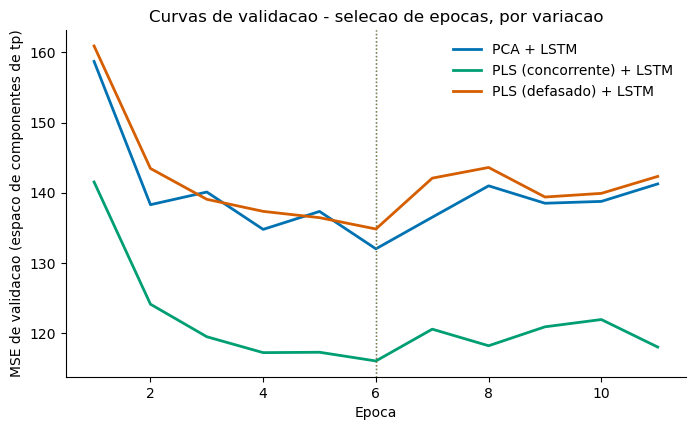

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for m in metodos_disponiveis:
    history = pd.read_csv(Path(RUN_DIRS[m]) / "history.csv")
    ax.plot(history["epoch"], history["val_mse_pca"], color=COLORS[m], lw=2, label=LABELS[m])
    ax.axvline(all_metrics[m]["best_epoch"], color=COLORS[m], lw=1, ls=":", alpha=0.6)

if metodos_disponiveis:
    ax.set_xlabel("Epoca")
    ax.set_ylabel("MSE de validacao (espaco de componentes de tp)")
    ax.set_title("Curvas de validacao - selecao de epocas, por variacao")
    ax.legend(frameon=False)
    plt.show()
else:
    print("Nenhuma variacao treinada ainda.")


## 3. Comparacao com os baselines

RMSE e MAE calculados na grade real (mm/dia), no conjunto de validacao interna
(2019-2022), para todas as variacoes treinadas e os dois baselines.

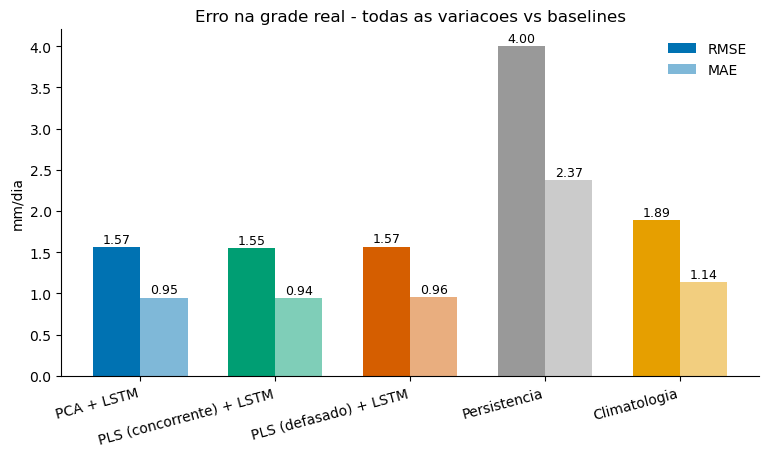

In [4]:
nomes = metodos_disponiveis + (["persistencia", "climatologia"] if metodos_disponiveis else [])


def get_metric(nome):
    if nome in metodos_disponiveis:
        return all_metrics[nome]["modelo"]
    return all_metrics[metodos_disponiveis[0]][nome]


if nomes:
    rmse_vals = [get_metric(n)["rmse"] for n in nomes]
    mae_vals = [get_metric(n)["mae"] for n in nomes]

    x = np.arange(len(nomes))
    largura = 0.35

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(x - largura / 2, rmse_vals, largura, label="RMSE", color=[COLORS[n] for n in nomes])
    ax.bar(x + largura / 2, mae_vals, largura, label="MAE", color=[COLORS[n] for n in nomes], alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([LABELS[n] for n in nomes], rotation=15, ha="right")
    ax.set_ylabel("mm/dia")
    ax.set_title("Erro na grade real - todas as variacoes vs baselines")
    ax.legend(frameon=False)

    for i, (r, m) in enumerate(zip(rmse_vals, mae_vals)):
        ax.text(i - largura / 2, r + 0.05, f"{r:.2f}", ha="center", fontsize=9)
        ax.text(i + largura / 2, m + 0.05, f"{m:.2f}", ha="center", fontsize=9)

    plt.show()
else:
    print("Nenhuma variacao treinada ainda.")


## 4. Erro por horizonte de previsao (lag)

Como o RMSE muda conforme o mes-alvo fica mais distante da origem, para cada
variacao. Esperado: erro cresce com o lag para os modelos e a persistencia; a
climatologia tende a ficar estavel (nao depende da origem).

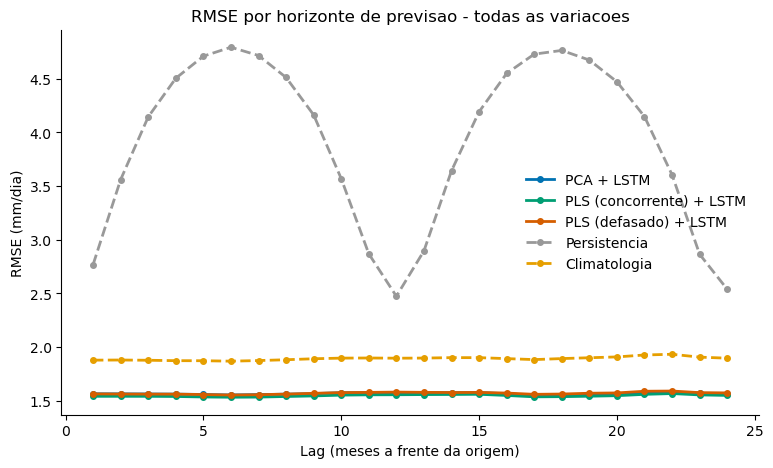

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for nome in nomes:
    por_lag = get_metric(nome).get("por_lag")
    if not por_lag:
        continue
    lags_ord = sorted(por_lag.keys(), key=int)
    rmse_lag = [por_lag[l]["rmse"] for l in lags_ord]
    ax.plot(
        [int(l) for l in lags_ord],
        rmse_lag,
        marker="o",
        ms=4,
        lw=2,
        color=COLORS[nome],
        ls=LINESTYLES[nome],
        label=LABELS[nome],
    )

if nomes:
    ax.set_xlabel("Lag (meses a frente da origem)")
    ax.set_ylabel("RMSE (mm/dia)")
    ax.set_title("RMSE por horizonte de previsao - todas as variacoes")
    ax.legend(frameon=False)
    plt.show()
else:
    print("Nenhuma variacao treinada ainda.")


## 5. Mapas espaciais de exemplo

Para alguns lags representativos (1, 3, 6, 12, 18, 24 meses, quando disponiveis
na validacao), compara o campo real de precipitacao com a previsao do modelo, os
dois baselines, e o erro (previsto - real). Mostra so **uma variacao por vez** (a
de melhor RMSE no leaderboard, por padrao) - troque `METODO_MAPAS` na celula
abaixo para ver outra.

Mostrando mapas espaciais de: PLS (concorrente) + LSTM


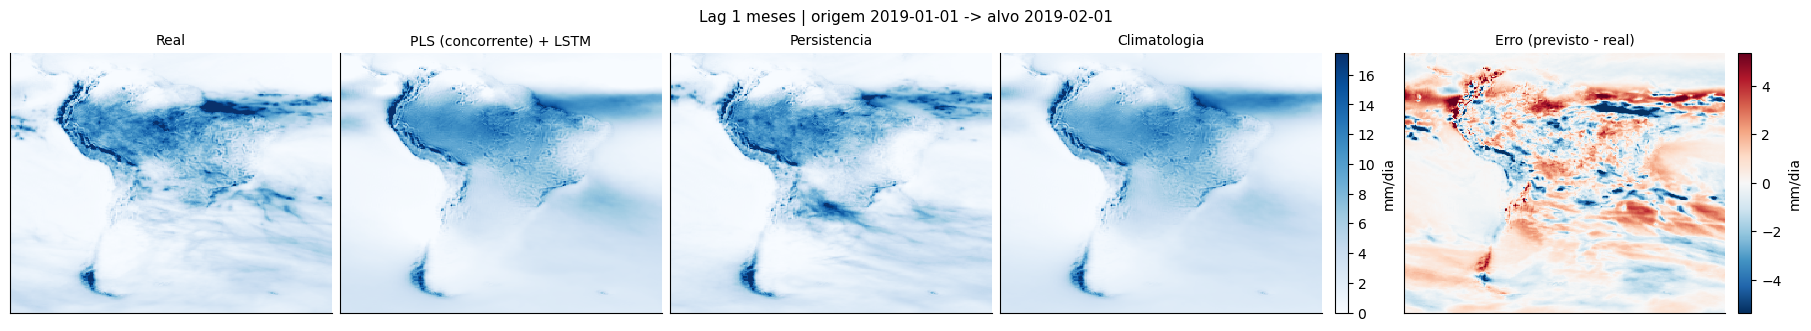

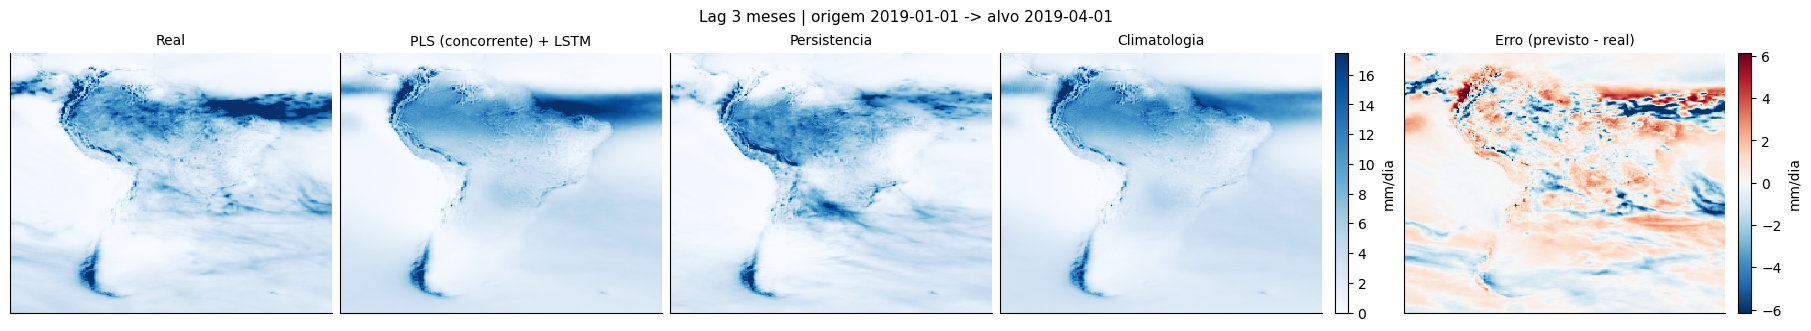

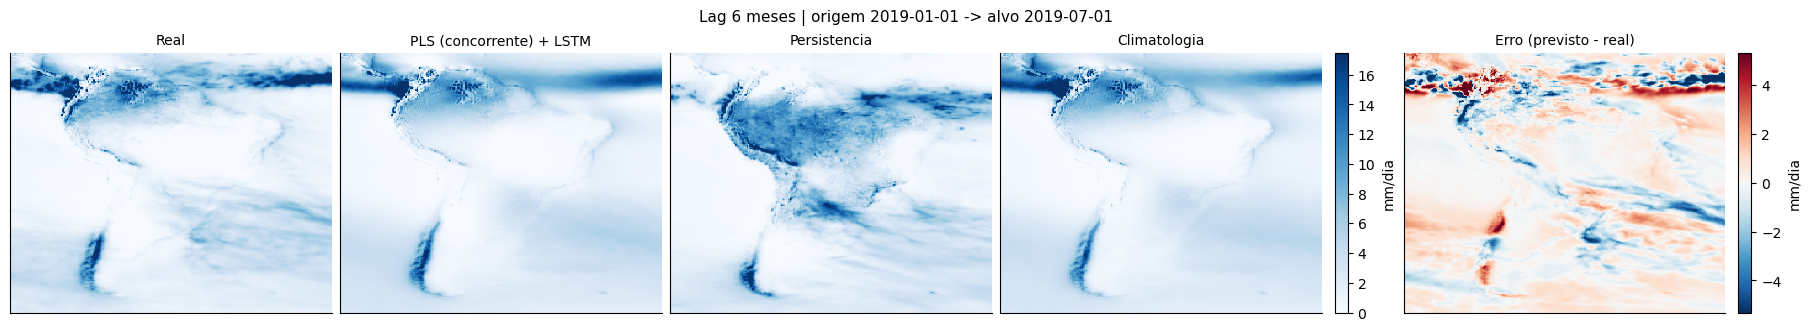

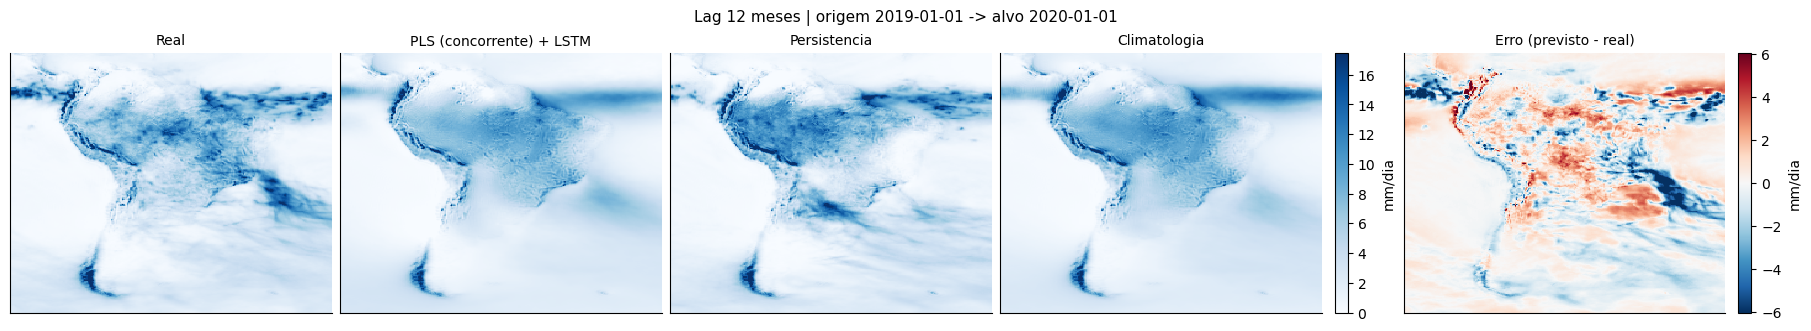

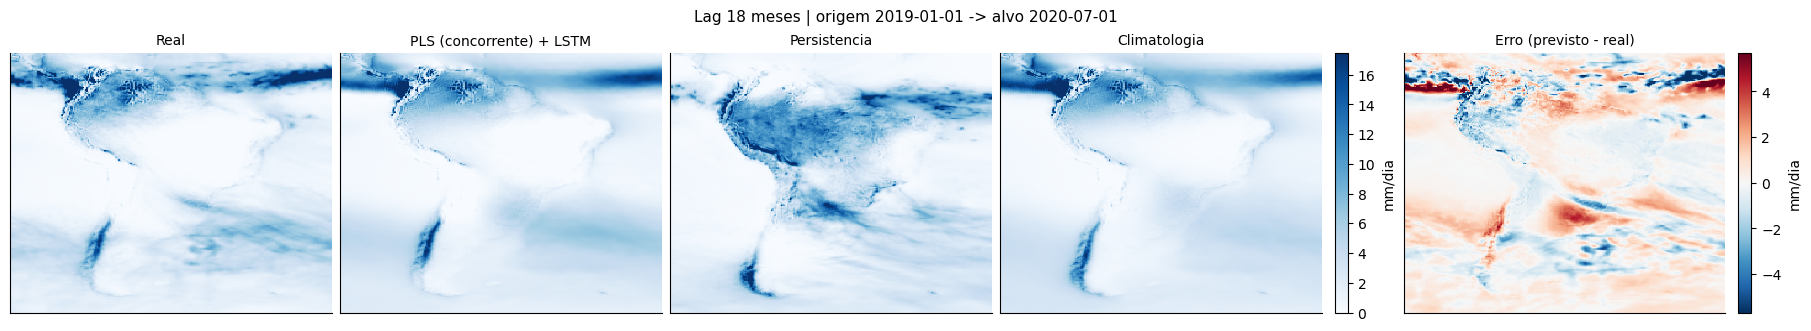

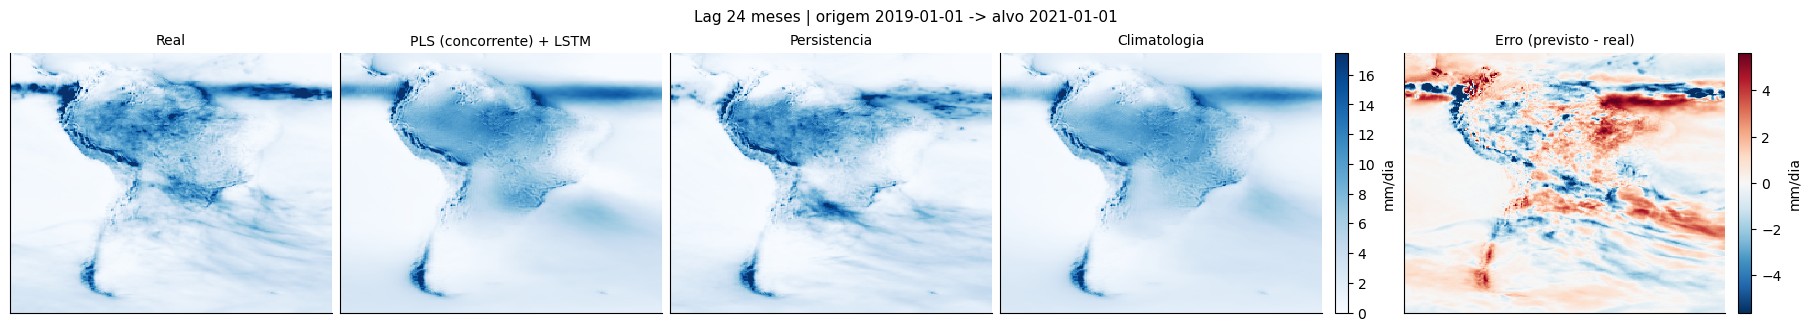

In [6]:
METODO_MAPAS = min(metodos_disponiveis, key=lambda m: all_metrics[m]["modelo"]["rmse"]) if metodos_disponiveis else None

if METODO_MAPAS is None:
    print("Nenhuma variacao treinada ainda.")
else:
    print(f"Mostrando mapas espaciais de: {LABELS[METODO_MAPAS]}")

    dados = np.load(f"{RUN_DIRS[METODO_MAPAS]}/sample_grids.npz")
    lat, lon = dados["lat"], dados["lon"]
    lags_amostra = dados["lags"]

    vmax_precip = np.nanpercentile(dados["true"], 99)

    for i, lag in enumerate(lags_amostra):
        fig, axes = plt.subplots(1, 5, figsize=(18, 3.2), constrained_layout=True)
        campos = [
            ("Real", dados["true"][i], "Blues", 0, vmax_precip),
            (LABELS[METODO_MAPAS], dados["pred"][i], "Blues", 0, vmax_precip),
            ("Persistencia", dados["persist"][i], "Blues", 0, vmax_precip),
            ("Climatologia", dados["clim"][i], "Blues", 0, vmax_precip),
        ]
        for ax, (titulo, campo, cmap, vmin, vmax) in zip(axes[:4], campos):
            im = ax.pcolormesh(lon, lat, campo, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
            ax.set_title(titulo, fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])
        fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04, label="mm/dia")

        erro = dados["pred"][i] - dados["true"][i]
        lim = np.nanpercentile(np.abs(erro), 99)
        im_err = axes[4].pcolormesh(lon, lat, erro, cmap="RdBu_r", vmin=-lim, vmax=lim, shading="auto")
        axes[4].set_title("Erro (previsto - real)", fontsize=10)
        axes[4].set_xticks([])
        axes[4].set_yticks([])
        fig.colorbar(im_err, ax=axes[4], fraction=0.046, pad=0.04, label="mm/dia")

        fig.suptitle(
            f"Lag {lag} meses | origem {dados['origin_date'][i]} -> alvo {dados['target_date'][i]}",
            fontsize=11,
        )
        plt.show()


## Notas

- Metricas e mapas sao do conjunto de **validacao interna** (origens 2019-2022,
  nunca usadas para treinar o modelo nesta fase) - ver `PLANO_TRABALHO.md`.
- O MSE de treino/validacao (secao 2) e sempre no espaco de componentes PCA de
  `tp` - `tp` e reduzido via PCA em todas as variacoes (so as variaveis
  atmosfericas mudam de metodo), entao a comparacao entre curvas e direta.
- O modelo final enviado para o Kaggle de cada variacao
  (`submissions/submission_<metodo>_lstm.csv`) foi retreinado com todo o
  historico 1940-2022, usando o numero de epocas escolhido aqui - o desempenho
  real no teste (2023-2024) pode diferir um pouco do medido na validacao
  interna.
- Para treinar as variacoes que aparecem como "ainda sem treino": `python3
  run_all_models.py --variations pca pls_concurrent pls_lagged` (ou so as que
  faltam).